Importación de Librerías

In [98]:
import pandas as pd
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt

Preprocesamiento

In [99]:
def extraer_caracteristicas(ruta_archivo):
    try:
        datos, frecuencia = librosa.load(ruta_archivo, sr=None)
        mfccs = librosa.feature.mfcc(y=datos, sr=frecuencia, n_mfcc=13)
        return np.mean(mfccs.T, axis=0)
    except Exception:
        return np.zeros(13)

df = pd.read_csv('dataset/set_a.csv')
df = df.dropna(subset=['label'])

etiquetas_unicas = df['label'].unique()
diccionario_etiquetas = {etiqueta: i for i, etiqueta in enumerate(etiquetas_unicas)}
df['label_num'] = df['label'].map(diccionario_etiquetas)


lista_caracteristicas = []
for archivo in df['fname']:
    ruta = f"dataset/{archivo}"
    caracteristicas = extraer_caracteristicas(ruta)
    lista_caracteristicas.append(caracteristicas)

X = np.array(lista_caracteristicas)
y = df['label_num'].values

print(f"Total de audios procesados: {X.shape[0]}")
print(f"Características extraídas por audio: {X.shape[1]} (MFCC)")

Total de audios procesados: 124
Características extraídas por audio: 13 (MFCC)


División entrenamiento, validación y prueba

In [100]:
m = len(y)
train_size = int(m * 0.8)
np.random.seed(42)
indices = np.random.permutation(m)
X, y = X[indices], y[indices]


X_development, y_development = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]


validation_size = int(len(X_development) * 0.2)
X_val_raw = X_development[:validation_size]
y_val = y_development[:validation_size]
X_train_raw = X_development[validation_size:]
y_train = y_development[validation_size:]


mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1
X_train_norm = (X_train_raw - mu) / sigma
X_val_norm = (X_val_raw - mu) / sigma
X_test_norm = (X_test - mu) / sigma


X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"Datos de Entrenamiento (X_train): {X_train_t.shape}")
print(f"Datos de Validación (X_val): {X_val_t.shape}")
print(f"Datos de Prueba (X_test): {X_test_t.shape}")

Datos de Entrenamiento (X_train): torch.Size([80, 13])
Datos de Validación (X_val): torch.Size([19, 13])
Datos de Prueba (X_test): torch.Size([25, 13])


Arquitectura, Optimización y Regularización

In [101]:
torch.manual_seed(42)
D_in = X_train_t.shape[1]
H1 = 16
D_out = len(etiquetas_unicas)

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H1),
    torch.nn.ReLU(),
    torch.nn.Linear(H1, D_out)
)

learning_rate = 0.001
l2_penalty = 0.05
epochs = 1000
batch_size = 16
patience = 100
min_delta = 0.0001

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
validation_dataset = torch.utils.data.TensorDataset(X_val_t, y_val_t)
test_dataset = torch.utils.data.TensorDataset(X_test_t, y_test_t)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("--- Hiperparámetros de Entrenamiento ---")
print(f"Características de entrada: {D_in}")
print(f"Clases de salida: {D_out}")
print(f"Tasa de aprendizaje (LR): {learning_rate}")
print(f"Regularización L2: {l2_penalty}")
print(f"Épocas máximas: {epochs}")
print(f"Tamaño de lote (Batch Size): {batch_size}")
print(f"Paciencia de Early Stopping: {patience}")

--- Hiperparámetros de Entrenamiento ---
Características de entrada: 13
Clases de salida: 4
Tasa de aprendizaje (LR): 0.001
Regularización L2: 0.05
Épocas máximas: 1000
Tamaño de lote (Batch Size): 16
Paciencia de Early Stopping: 100


Entrenamiento y Demostración de Ausencia de Overfitting

Época 30/1000 | Loss Train: 0.8414 | Loss Val: 0.8617
Época 60/1000 | Loss Train: 0.7558 | Loss Val: 0.7771
Época 90/1000 | Loss Train: 0.7126 | Loss Val: 0.7320
Época 120/1000 | Loss Train: 0.6811 | Loss Val: 0.6998
Época 150/1000 | Loss Train: 0.6571 | Loss Val: 0.6796
Época 180/1000 | Loss Train: 0.6393 | Loss Val: 0.6621
Época 210/1000 | Loss Train: 0.6264 | Loss Val: 0.6504
Época 240/1000 | Loss Train: 0.6153 | Loss Val: 0.6420
Época 270/1000 | Loss Train: 0.6089 | Loss Val: 0.6371
Época 300/1000 | Loss Train: 0.6045 | Loss Val: 0.6311
Época 330/1000 | Loss Train: 0.6010 | Loss Val: 0.6278
Época 360/1000 | Loss Train: 0.5991 | Loss Val: 0.6264
Época 390/1000 | Loss Train: 0.5979 | Loss Val: 0.6238
Época 420/1000 | Loss Train: 0.5964 | Loss Val: 0.6225
Época 450/1000 | Loss Train: 0.5956 | Loss Val: 0.6220
Época 480/1000 | Loss Train: 0.5950 | Loss Val: 0.6212
Época 510/1000 | Loss Train: 0.5944 | Loss Val: 0.6205
Época 540/1000 | Loss Train: 0.5941 | Loss Val: 0.6184
Época 570/100

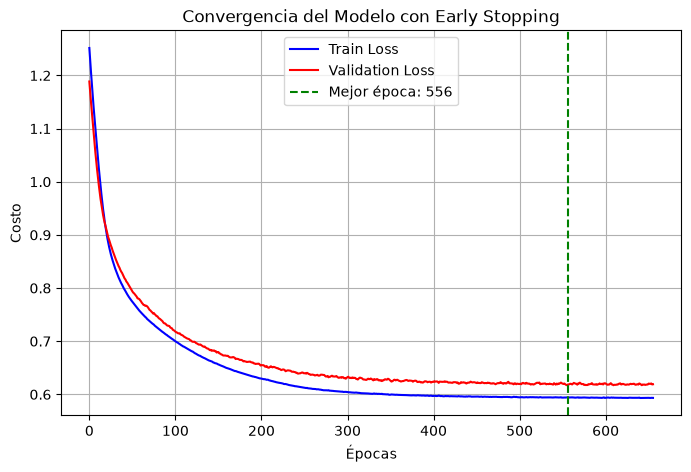

In [102]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for e in range(1, epochs + 1):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in validation_loader:
            val_logits = model(X_batch)
            loss_v = criterion(val_logits, y_batch)
            val_loss += loss_v.item()

    val_loss = val_loss / len(validation_loader)
    val_losses.append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_epoch = e
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "mejor_modelo_audio.pt")
    else:
        epochs_without_improvement += 1

    if e % 30 == 0:
        print(f"Época {e}/{epochs} | Loss Train: {train_loss:.4f} | Loss Val: {val_loss:.4f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping en la época {e}. Mejor época: {best_epoch}")
        break

model.load_state_dict(torch.load("mejor_modelo_audio.pt"))
print(f"Modelo restaurado desde la mejor época: {best_epoch}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red")
plt.axvline(best_epoch, color="green", linestyle="--", label=f"Mejor época: {best_epoch}")
plt.xlabel("Épocas")
plt.ylabel("Costo")
plt.title("Convergencia del Modelo con Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

metricas

In [103]:
model.eval()
correctos = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predecidos = torch.max(outputs, 1)
        total += y_batch.size(0)
        correctos += (predecidos == y_batch).sum().item()

precision = 100 * correctos / total
print("\n¡Evaluación finalizada!")
print(f"Total de audios de prueba evaluados: {total}")
print(f"Audios clasificados correctamente: {correctos}")
print(f"Precisión final del modelo: {precision:.2f}%")


¡Evaluación finalizada!
Total de audios de prueba evaluados: 25
Audios clasificados correctamente: 19
Precisión final del modelo: 76.00%
